In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import json

In [3]:
def within_minus_between_similarity(representations, rows_meta):
    """Compute within-group minus between-group cosine similarity over time.

    For each timestep and each subgroup, computes:
        mean cosine similarity between samples sharing the same group_id
      - mean cosine similarity between samples with different group_ids

    Parameters
    ----------
    representations : np.ndarray, shape (n_steps, n_samples, dim)
    rows_meta : list of dicts with keys 'subgroup', 'group_id', 'item_id'

    Returns
    -------
    dict mapping subgroup name -> np.ndarray of shape (n_steps,)
    """
    subgroups = list(dict.fromkeys(r['subgroup'] for r in rows_meta))
    indices_by_sg = {
        sg: np.array([i for i, r in enumerate(rows_meta) if r['subgroup'] == sg])
        for sg in subgroups
    }
    group_ids_by_sg = {
        sg: np.array([rows_meta[i]['group_id'] for i in idxs])
        for sg, idxs in indices_by_sg.items()
    }

    result = {}
    for sg in subgroups:
        idxs = indices_by_sg[sg]
        group_ids = group_ids_by_sg[sg]  # shape (n_sg_samples,)

        # Boolean mask: same_group[i, j] = True iff samples i and j share group_id
        same_group = group_ids[:, None] == group_ids[None, :]  # (n, n)
        # Exclude diagonal (self-similarity)
        np.fill_diagonal(same_group, False)
        diff_group = ~same_group
        np.fill_diagonal(diff_group, False)

        n_steps = representations.shape[0]
        scores = np.empty(n_steps)

        for t in range(n_steps):
            reps = representations[t][idxs]  # (n_sg_samples, dim)
            # Compute the correlation
            cosim = np.corrcoef(reps, rowvar=True)

            within = cosim[same_group].mean() if same_group.any() else 0.0
            between = cosim[diff_group].mean() if diff_group.any() else 0.0
            scores[t] = within - between

        result[sg] = scores
    return result


In [4]:
SUBGROUP_COLORS = {
    'no face':        'grey',
    'different face': 'red',
    'same face':      'blue',
}


def _detect_networks(run_dir, probe_name, layer_key):
    """Return sorted list of network indices present in run_dir."""
    prefix = f'{probe_name}_net'
    suffix = f'_{layer_key}.npy'
    nets = []
    for fname in os.listdir(run_dir):
        if fname.startswith(prefix) and fname.endswith(suffix):
            middle = fname[len(prefix):-len(suffix)]
            if middle.isdigit():
                nets.append(int(middle))
    return sorted(nets)


def _load_run(run_dir, probe_name, layer_key, net_indices):
    """Load and return (reps_by_net, rows_meta, steps).

    reps_by_net : dict {net_idx: (n_steps, n_samples, dim)}
    """
    rows_path = os.path.join(run_dir, f'{probe_name}_rows.json')
    steps_path = os.path.join(run_dir, f'{probe_name}_steps.npy')
    with open(rows_path) as f:
        rows_meta = json.load(f)
    steps = np.load(steps_path)
    reps_by_net = {
        ni: np.load(os.path.join(run_dir, f'{probe_name}_net{ni}_{layer_key}.npy'))
        for ni in net_indices
    }
    return reps_by_net, rows_meta, steps


def _plot_on_ax(ax, all_scores, steps_ref, title):
    for sg, arrays in all_scores.items():
        mat = np.stack(arrays, axis=0)   # (n_seeds, n_steps)
        mean = mat.mean(axis=0)
        sem  = mat.std(axis=0) / np.sqrt(len(arrays))
        label = sg.replace('_', ' ')
        color = SUBGROUP_COLORS.get(label, None)
        ax.plot(steps_ref, mean, label=label, color=color)
        ax.fill_between(steps_ref, mean - sem, mean + sem, alpha=0.2, color=color)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Trials')
    ax.set_ylabel('Pairmate similarity')
    ax.set_title(title)
    ax.legend()


def plot_pairmate_similarity(
    multirun_dir,
    title,
    layer_key='hidden_0',
    probe_name='representations',
    mode='panels',
    network_labels=("Network 1", "Network 2")
):
    """Plot within-minus-between-group representational similarity across seeds.

    Loads all seed runs from *multirun_dir*, computes within-minus-between
    similarity per network, and plots mean ± SEM per subgroup.

    Parameters
    ----------
    multirun_dir : str
        Path to a Hydra multirun directory whose subdirectories each contain
        one seed's run.
    title : str
        Plot title (used as suptitle when multiple panels are shown).
    layer_key : str
        Layer suffix identifying which layer to load, e.g. ``'hidden_0'``.
        Files are expected as ``{probe_name}_net{N}_{layer_key}.npy``.
    probe_name : str
        Stem of the evaluation probe files (default ``'representations'``).
    mode : str
        ``'panels'`` — one subplot per network (default).
        ``'concat'`` — concatenate all networks' representations along the
        feature dimension before computing similarity.

    Returns
    -------
    fig, axes  (axes is a single Axes when there is only one network)
    """
    run_dirs = sorted([
        os.path.join(multirun_dir, d)
        for d in os.listdir(multirun_dir)
        if os.path.isdir(os.path.join(multirun_dir, d))
    ])
    # Filter to dirs that actually have the expected files
    run_dirs = [
        d for d in run_dirs
        if os.path.isfile(os.path.join(d, f'{probe_name}_rows.json'))
    ]
    if not run_dirs:
        raise ValueError(f"No valid runs found in {multirun_dir!r}.")

    net_indices = _detect_networks(run_dirs[0], probe_name, layer_key)
    if not net_indices:
        raise ValueError(
            f"No files matching '{probe_name}_net*_{layer_key}.npy' found in {run_dirs[0]!r}."
        )

    steps_ref = None

    if mode == 'concat':
        # Accumulate per-seed concatenated representations
        all_scores = {}
        for run_dir in run_dirs:
            reps_by_net, rows_meta, steps = _load_run(run_dir, probe_name, layer_key, net_indices)
            if steps_ref is None:
                steps_ref = steps
            # Concatenate along feature dim: (n_steps, n_samples, sum_of_dims)
            reps_concat = np.concatenate(
                [reps_by_net[ni] for ni in net_indices], axis=2
            )
            seed_scores = within_minus_between_similarity(reps_concat, rows_meta)
            for sg, arr in seed_scores.items():
                all_scores.setdefault(sg, []).append(arr)

        fig, ax = plt.subplots()
        _plot_on_ax(ax, all_scores, steps_ref, title)
        plt.tight_layout()
        return fig, ax

    else:  # 'panels'
        n_nets = len(net_indices)
        fig, axes = plt.subplots(1, n_nets, figsize=(5 * n_nets, 4), squeeze=False)
        axes = axes[0]  # shape: (n_nets,)

        for panel_idx, ni in enumerate(net_indices):
            all_scores = {}
            for run_dir in run_dirs:
                reps_by_net, rows_meta, steps = _load_run(
                    run_dir, probe_name, layer_key, net_indices
                )
                if steps_ref is None:
                    steps_ref = steps
                seed_scores = within_minus_between_similarity(reps_by_net[ni], rows_meta)
                for sg, arr in seed_scores.items():
                    all_scores.setdefault(sg, []).append(arr)

            panel_title = network_labels[ni] if n_nets > 1 else title
            _plot_on_ax(axes[panel_idx], all_scores, steps_ref, panel_title)

        if n_nets > 1:
            fig.suptitle(title)
        plt.tight_layout()
        return fig, axes[0] if n_nets == 1 else axes


In [707]:
folder = '../multirun/2026-06-21/21-29-49'

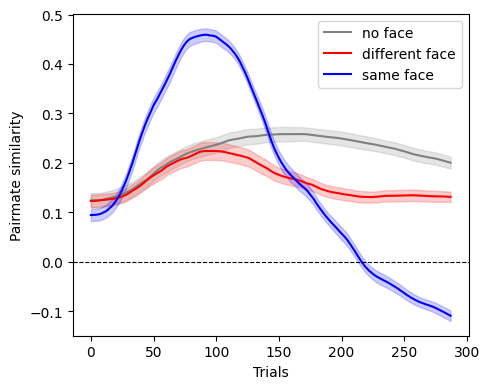

In [5]:
fig, axes = plot_pairmate_similarity('../data/favila2016/linear_network', title='', mode='panels')
plt.show()


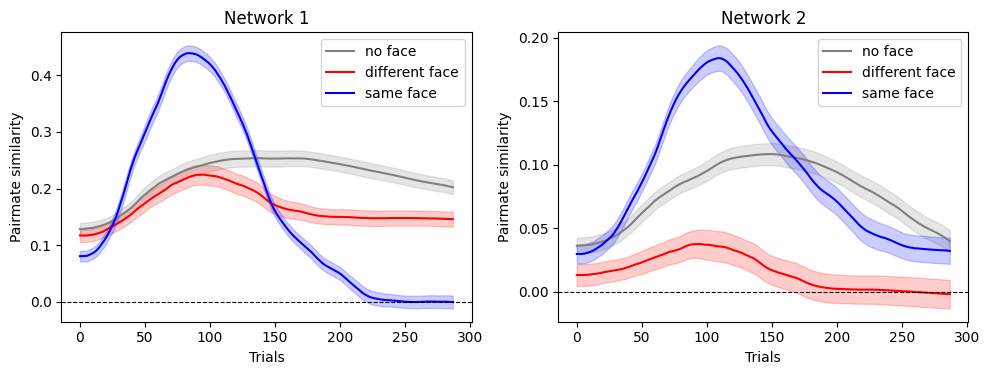

In [8]:
fig, axes = plot_pairmate_similarity('../data/favila2016/dual_stream_linear', title='', mode='panels')
plt.show()


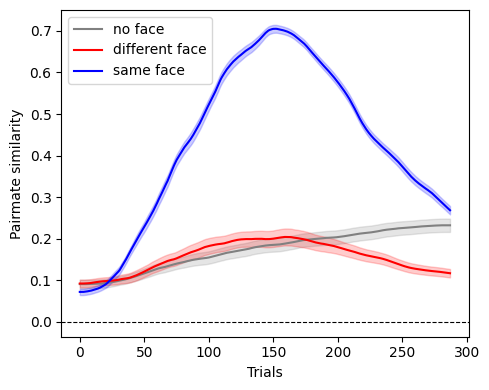

In [9]:
fig, axes = plot_pairmate_similarity('../data/favila2016/relu_network', title='', mode='panels')
plt.show()


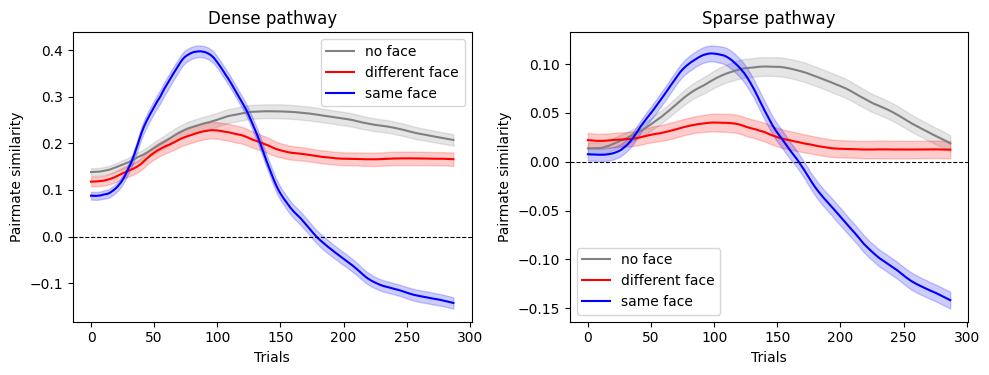

In [706]:
fig, axes = plot_pairmate_similarity(folder, title='', mode='panels', network_labels=('Dense pathway', 'Sparse pathway'))
plt.show()
